# 11. 재무지표 확장 — 6-팩터 구조 (Risk/Momentum/Growth/Valuation/Quality/Size)
09번에서 PER 하나만 추가했을 때 정확도가 baseline 대비 소폭 개선됐다(0.517→0.525 등). 하지만 PER 하나로는 밸류에이션 한쪽 측면만 본 것이라, 09번과 같은 5년 통제 실험 틀 위에 PBR/ROE/부채비율/매출성장률/log 시가총액을 추가해 baseline / +PER / +전체재무지표 세 모델을 나란히 비교한다.

## 6개 팩터로 정리한 이유
지표 10개를 그냥 나열하는 대신, 실제 팩터 투자에서 쓰는 분류(MSCI Factor Box와 유사한 구조)로 묶었다 — "지표가 많다"가 아니라 "서로 다른 6개의 경제적 관점으로 기업을 설명한다"는 게 목표다.

| 팩터 | 지표 | 의미 |
|---|---|---|
| **Risk** | Beta, Volatility, Debt/Equity | 시장 민감도 + 가격 변동성 + 재무 레버리지 |
| **Momentum** | Return_Nd, RSI | 과거 가격 움직임 |
| **Growth** | Revenue Growth | 기업 자체의 성장성 (가격이 아닌 펀더멘털 모멘텀) |
| **Valuation** | PER, PBR | 이익 및 순자산 대비 가격 수준 |
| **Quality** | ROE | 자본을 얼마나 효율적으로 이익으로 전환하는가 |
| **Size** | Log Market Cap | 기업 규모 (log 변환 — 시가총액은 몇 자릿수씩 벌어지는 분포라 raw 값이면 로지스틱회귀 거리 기반 스케일링과 트리 분할 기준이 초대형주로 쏠린다) |

**MDD(최대낙폭)는 의도적으로 제외했다.** 04번에서 다중공선성 때문에 뺐던 지표(MDD/downside_volatility/ma_gap/momentum/cagr_10y)를 팩터 구조 맞추자고 다시 넣으면 그 결정 자체와 모순된다 — 게다가 MDD는 "기업의 현재 특성"이 아니라 과거 가격 경로에서 파생된 값이라, 이미 있는 volatility/return과 정보가 겹친다. 대신 MDD는 **종목 선정 feature가 아니라 전략 성과 평가**(`backtest.py`의 `max_drawdown`)에 쓴다 — "이 종목을 고를까"와 "고른 포트폴리오가 실제로 얼마나 위험했나"는 서로 다른 질문이기 때문이다.

## point-in-time 처리 — PER과 동일한 원칙
회계연도 종료일에 그 실적이 바로 공개되는 게 아니라 몇 주~몇 달 뒤 보고서로 나온다. `src/fundamentals.py`의 `REPORTING_LAG_DAYS`(90일) 이후부터만 그 실적을 "쓸 수 있는 정보"로 취급해 lookahead bias를 막는다 — income statement(EPS/순이익/매출)와 balance sheet(자기자본/부채/발행주식수) 둘 다 같은 원칙을 적용한다.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path('/Users/choedasom/lab_middle_project')
assert (PROJECT_ROOT / 'src' / 'fundamentals.py').is_file(), f'경로 확인 필요: {PROJECT_ROOT}'
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

for m in list(sys.modules):
    if m == 'src' or m.startswith('src.'):
        del sys.modules[m]

import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score

from src.performance import add_forward_returns
from src.ml_selection import (
    add_relative_label, time_split, train_models, predict_all, FEATURE_METRICS,
    FACTOR_GROUPS, metric_to_factor,
)
from src.fundamentals import fetch_income_statement_history, fetch_balance_sheet_history, add_fundamental_ratios

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
final_df = pd.read_parquet(PROCESSED_DIR / 'final_df.parquet')
rebalance_30df = pd.read_parquet(PROCESSED_DIR / 'rebalance_30df.parquet')

recent = rebalance_30df[rebalance_30df['Date'] >= '2021-01-01'].copy()
print(f'2021~2026 구간: {recent.shape}, {recent["Date"].nunique()}개 시점, {recent["Ticker"].nunique()}종목')

2021~2026 구간: (22855, 6), 46개 시점, 590종목


## 재무지표 결합 (PER + 확장 5개)

In [2]:
tickers = sorted(recent['Ticker'].unique())

income_df = fetch_income_statement_history(tickers)
balance_df = fetch_balance_sheet_history(tickers)
print(f'손익계산서: {income_df["Ticker"].nunique()}종목 | 재무상태표: {balance_df["Ticker"].nunique()}종목')

close_prices = final_df[['Date', 'Ticker', 'Close']]
recent_with_price = recent.merge(close_prices, on=['Date', 'Ticker'], how='left')
recent_with_fund = add_fundamental_ratios(recent_with_price, income_df, balance_df)

fund_cols = ['per', 'pbr', 'roe', 'debt_ratio', 'revenue_growth', 'log_market_cap']
print('\n결측률 (전체 대비):')
print(recent_with_fund[fund_cols].isna().mean().round(3))

손익계산서: 554종목 | 재무상태표: 554종목



결측률 (전체 대비):
per               0.458
pbr               0.465
roe               0.467
debt_ratio        0.468
revenue_growth    0.613
log_market_cap    0.427
dtype: float64


## revenue_growth가 실제로 몇 년치를 통째로 지우는가
"결측률 61.3%"가 추상적이니, `dropna` 전 원본에서 연도별 결측률을 직접 찍어서 어느 연도가 얼마나 빠지는지 확인한다.

In [3]:
by_year = recent_with_fund.copy()
by_year['year'] = by_year['Date'].dt.year
year_missing = by_year.groupby('year')[fund_cols].apply(lambda g: g.isna().mean())
print('연도별 재무지표 결측률:')
print(year_missing.round(3))

연도별 재무지표 결측률:
        per    pbr    roe  debt_ratio  revenue_growth  log_market_cap
year                                                                 
2021  1.000  1.000  1.000       1.000           1.000           1.000
2022  0.993  0.996  0.996       0.996           1.000           0.996
2023  0.310  0.315  0.318       0.318           0.994           0.263
2024  0.083  0.091  0.095       0.097           0.274           0.025
2025  0.059  0.079  0.083       0.086           0.016           0.016
2026  0.066  0.069  0.072       0.078           0.006           0.007


## 라벨 구성 및 train/test 분할 (세 모델셋 모두 같은 표본 사용)
09번과 같은 원칙: 재무지표가 하나라도 결측인 행은 통째로 제외해서, baseline / +PER / +전체재무지표 세 모델을 **완전히 같은 종목·시점**으로 비교한다. 그래야 성능 차이가 표본 차이가 아니라 피처 자체의 효과라고 말할 수 있다.

In [4]:
baseline_cols = [f'{m}_30d' for m in FEATURE_METRICS]
per_cols = baseline_cols + ['per']
full_cols = baseline_cols + fund_cols

perf = add_forward_returns(recent_with_fund, final_df)
perf = perf.dropna(subset=[*full_cols, 'forward_return'])  # 6개 재무지표 전부 있는 행만 -> 세 모델셋 공정 비교
labeled = add_relative_label(perf)

print(f'공통 표본: {labeled.shape}, {labeled["Date"].nunique()}개 시점')

train_dates, test_dates = time_split(labeled['Date'].unique().tolist(), train_ratio=0.7)
print(f'train: {len(train_dates)}개 시점, test: {len(test_dates)}개 시점')

train = labeled[labeled['Date'].isin(train_dates)]
test = labeled[labeled['Date'].isin(test_dates)].copy()
print(f'train rows: {len(train)}, test rows: {len(test)}')

공통 표본: (7321, 22), 22개 시점
train: 15개 시점, test: 7개 시점
train rows: 4278, test rows: 3043


## baseline(4개) vs +PER(5개) vs +전체재무지표(10개) 비교

In [5]:
results = {}
for label, cols in [
    ('baseline (4개)', baseline_cols),
    ('+PER (5개)', per_cols),
    ('+전체재무지표 (10개)', full_cols),
]:
    fitted = train_models(train[cols], train['outperform_peers'])
    preds = predict_all(fitted, test[cols])
    row = {}
    for name in ['random_forest', 'logistic', 'xgboost']:
        row[f'{name}_acc'] = accuracy_score(test['outperform_peers'], preds[name])
        row[f'{name}_auc'] = roc_auc_score(test['outperform_peers'], preds[name])
    results[label] = row
    results[label]['_fitted'] = fitted
    results[label]['_preds'] = preds

comparison = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if not kk.startswith('_')} for k, v in results.items()}).T
comparison.round(3)

,random_forest_acc,random_forest_auc,logistic_acc,logistic_auc,xgboost_acc,xgboost_auc
baseline (4개),0.503,0.503,0.523,0.522,0.505,0.505
+PER (5개),0.507,0.507,0.523,0.523,0.516,0.516
+전체재무지표 (10개),0.506,0.506,0.525,0.525,0.513,0.513


## 합의 추천(consensus) 백테스트 비교
`predict_all()`의 `consensus` 컬럼은 `pred_df.all(axis=1)` — **랜덤포레스트·로지스틱·XGBoost 세 모델이 전부 "outperform(1)"이라고 예측한 종목만** True다. 셋 중 하나라도 반대하면 추천에서 빠지는, 상당히 보수적인 규칙이다. 그래서 합의 비율(True 비율) 자체가 "몇 종목이 뽑혔는지"뿐 아니라 "세 모델의 예측이 서로 얼마나 겹치는지"도 같이 반영한다 — 아래에서 합의 비율이 23.7%→24.1%→27.0%로 늘어나는 걸 "모델이 더 자신 있게 잘 골랐다"로 읽으면 안 되는 이유다.

In [6]:
for label in results:
    preds = results[label]['_preds']
    t = test.copy()
    t['consensus'] = preds['consensus'].values
    bt = t.groupby('consensus')['forward_return'].agg(n='count', mean='mean', std='std')
    bt['return_per_risk'] = bt['mean'] / bt['std']
    print(f'=== {label} ===')
    print(bt.rename(index={True: '합의 추천', False: '나머지'}))
    print()

=== baseline (4개) ===
              n      mean       std  return_per_risk
consensus                                           
나머지        2321  0.008153  0.105818         0.077046
합의 추천       722  0.027276  0.145783         0.187098

=== +PER (5개) ===
              n      mean       std  return_per_risk
consensus                                           
나머지        2311  0.009111  0.106410         0.085624
합의 추천       732  0.023989  0.144311         0.166230

=== +전체재무지표 (10개) ===
              n      mean       std  return_per_risk
consensus                                           
나머지        2220  0.009108  0.106932         0.085178
합의 추천       823  0.022352  0.139622         0.160088



## Walk-forward 검증 — 단일 70/30 분할 하나로 충분한가
`src/ml_selection.py`에 이미 만들어둔 `walk_forward_splits()`(08번에서 사용)를 여기서도 적용한다. 다만 이 노트북의 공통 표본은 10개 지표가 전부 있어야 해서 실제 날짜 범위가 **2023-10~2026-04로 줄어든다**(revenue_growth가 2개 회계연도를 요구해서 2021~2022는 거의 100% 결측 — 바로 위 진단 셀 참고) — 08번처럼 `min_train_years=5`를 쓰면 fold가 0개가 되므로, 여기서는 `min_train_years=1`로 낮춰 연도별 3개 fold(test 2024/2025/2026)를 만든다. fold마다 baseline/+PER/+전체재무지표를 같은 학습·평가 데이터로 다시 비교한다.

**주의**: 첫 fold(test 2024)는 train이 2023-10~12의 3개 시점, **23행·12종목**뿐이다 — 통계적으로 거의 무의미한 크기이므로 이 fold의 결과는 참고만 하고 결론의 근거로 쓰지 않는다.

In [7]:
from src.ml_selection import walk_forward_splits

wf_splits = walk_forward_splits(labeled['Date'].unique().tolist(), min_train_years=1)
print(f'{len(wf_splits)}개 fold\n')

wf_rows = []
for tr_dates, te_dates in wf_splits:
    fold_train = labeled[labeled['Date'].isin(tr_dates)]
    fold_test = labeled[labeled['Date'].isin(te_dates)]
    test_year = min(te_dates).year

    print(f'--- test {test_year} ---')
    print(f'  train 기간: {min(tr_dates).date()} ~ {max(tr_dates).date()} ({len(tr_dates)}개 시점, {len(fold_train)}행, {fold_train["Ticker"].nunique()}종목)')
    print(f'  test  기간: {min(te_dates).date()} ~ {max(te_dates).date()} ({len(te_dates)}개 시점, {len(fold_test)}행, {fold_test["Ticker"].nunique()}종목)')

    for label, cols in [('baseline (4개)', baseline_cols), ('+PER (5개)', per_cols), ('+전체재무지표 (10개)', full_cols)]:
        fold_fitted = train_models(fold_train[cols], fold_train['outperform_peers'])
        fold_preds = predict_all(fold_fitted, fold_test[cols])
        aucs = [roc_auc_score(fold_test['outperform_peers'], fold_preds[m]) for m in ['random_forest', 'logistic', 'xgboost']]
        wf_rows.append({
            'test_year': test_year, 'feature_set': label,
            'auc_mean_3model': sum(aucs) / 3, 'n_train_rows': len(fold_train), 'n_test_rows': len(fold_test),
        })
    print()

wf_df = pd.DataFrame(wf_rows)
wf_df.pivot(index='test_year', columns='feature_set', values='auc_mean_3model').round(3)

3개 fold

--- test 2024 ---
  train 기간: 2023-10-03 ~ 2023-12-28 (3개 시점, 23행, 12종목)
  test  기간: 2024-02-12 ~ 2024-12-11 (8개 시점, 2519행, 428종목)



--- test 2025 ---
  train 기간: 2023-10-03 ~ 2024-12-11 (11개 시점, 2542행, 428종목)
  test  기간: 2025-01-28 ~ 2025-11-26 (8개 시점, 3481행, 462종목)



--- test 2026 ---
  train 기간: 2023-10-03 ~ 2025-11-26 (19개 시점, 6023행, 463종목)
  test  기간: 2026-01-12 ~ 2026-04-09 (3개 시점, 1298행, 449종목)


feature_set,+PER (5개),+전체재무지표 (10개),baseline (4개)
test_year,,,
2024,0.534,0.518,0.532
2025,0.518,0.523,0.524
2026,0.497,0.503,0.493


## +전체재무지표 모델의 피처 중요도

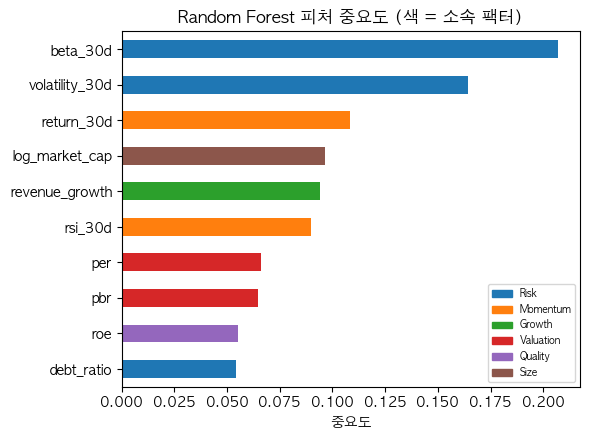

In [8]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

factor_colors = {
    'Risk': '#1f77b4', 'Momentum': '#ff7f0e', 'Growth': '#2ca02c',
    'Valuation': '#d62728', 'Quality': '#9467bd', 'Size': '#8c564b',
}

rf_full = results['+전체재무지표 (10개)']['_fitted']['models']['random_forest']
importance = pd.Series(rf_full.feature_importances_, index=full_cols).sort_values()
factor_of = {c: metric_to_factor(c) for c in full_cols}

fig, ax = plt.subplots(figsize=(6, 4.5))
colors = [factor_colors[factor_of[c]] for c in importance.index]
importance.plot.barh(ax=ax, color=colors)
ax.set_xlabel('중요도')
ax.set_title('Random Forest 피처 중요도 (색 = 소속 팩터)')

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in factor_colors.values()]
ax.legend(handles, factor_colors.keys(), fontsize=7, loc='lower right')
plt.tight_layout()
plt.show()

## 팩터 레벨 중요도 — "개별 지표"가 아니라 "어떤 투자 요인이 기여하는가"
위 차트는 지표 하나하나의 중요도다. 아래는 같은 팩터에 속한 지표들의 중요도를 합산해서, "beta가 중요하다"가 아니라 "Risk 팩터 자체가 예측에 얼마나 기여하는가"를 본다.

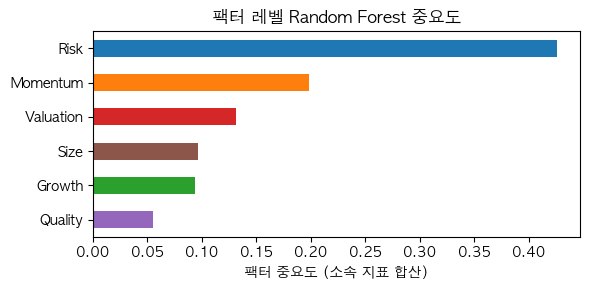

Risk         0.426
Momentum     0.198
Valuation    0.131
Size         0.096
Growth       0.094
Quality      0.055
dtype: float64


In [9]:
factor_importance = importance.groupby(factor_of).sum().sort_values()

fig, ax = plt.subplots(figsize=(6, 3))
colors = [factor_colors[f] for f in factor_importance.index]
factor_importance.plot.barh(ax=ax, color=colors)
ax.set_xlabel('팩터 중요도 (소속 지표 합산)')
ax.set_title('팩터 레벨 Random Forest 중요도')
plt.tight_layout()
plt.show()

print(factor_importance.sort_values(ascending=False).round(3))

## 결론

| | baseline (4개) | +PER (5개) | +전체재무지표 (10개) |
|---|---|---|---|
| Random Forest AUC | 0.503 | 0.507 | 0.506 |
| Logistic AUC | 0.522 | 0.523 | 0.525 |
| XGBoost AUC | 0.505 | 0.516 | 0.513 |
| 합의 추천 위험대비수익 | **0.187** | 0.166 | 0.160 |

**실험 설계: 왜 공통 표본으로 통제했는가.** baseline이 더 많은 시점을 쓰고 +전체재무지표가 적은 시점을 쓰면, 정확도 차이가 "피처 효과"인지 "표본 차이"인지 구분할 수 없다. 그래서 10개 지표가 전부 있는 행만 남겨(`dropna(subset=[*full_cols, ...])`) baseline/+PER/+전체재무지표를 **완전히 동일한 시점**으로 비교했다 — 통제 실험으로서는 타당한 설계다. (09번의 baseline 0.517~0.519와 이 표를 직접 비교해선 안 된다 — 09번은 PER만 요구해 더 많은 시점을 썼다.)

**단, 표본 감소와 피처 효과는 분리해서 읽어야 한다.** `revenue_growth`가 2개 회계연도를 요구해서 2021~2022는 거의 100% 결측이고(연도별 결측률 진단 참고), 실질적으로 쓸 수 있는 공통 표본은 2023-10 이후부터다 — 표본이 22개 시점(train 15 / test 7)까지 줄었다. **전체 재무지표를 동시에 사용할 수 있는 공통 표본으로 통제한 결과, 재무지표 추가에 따른 예측력 개선은 미미했다. 다만 재무정보 availability 문제로 평가 가능한 test 시점이 7개로 제한되어 결과의 통계적 안정성에는 한계가 있다.**

**AUC 자체는 모델마다 방향이 갈린다** — Random Forest는 거의 변화 없음(0.503→0.507→0.506), Logistic은 조금씩 개선(0.522→0.523→0.525), XGBoost는 +PER에서 개선 후 +전체재무지표에서 소폭 하락(0.505→0.516→0.513). **"재무지표 추가가 실패했다"는 너무 강한 결론이다 — 정확히는 "모델별로 미세한 개선을 보였지만, 일관된 성능 향상은 확인되지 않았다."**

**Walk-forward(연도별 3개 fold)로 재확인하면 순위 자체가 fold마다 뒤집힌다:**

| test 연도 | baseline | +PER | +전체재무지표 | 1위 |
|---|---|---|---|---|
| 2024 (train 23행·12종목 — 참고용) | 0.532 | 0.534 | 0.518 | (표본 너무 작아 무의미) |
| 2025 (train 2,542행·428종목) | **0.524** | 0.518 | 0.523 | baseline |
| 2026 (train 6,023행·463종목) | 0.493 | 0.497 | **0.503** | +전체재무지표 |

2024 fold는 train이 23행·12종목뿐이라 통계적으로 무의미해 참고만 한다. 신뢰할 수 있는 나머지 두 fold만 봐도 2025는 baseline이, 2026은 +전체재무지표가 이긴다 — **어느 한 feature set이 계속 이기는 패턴이 없다.** 단일 70/30 분할에서 "+PER이 가장 낫다"고 나온 결과는 그 특정 test 구간 하나에 국한된 우연일 가능성이 크다.

**반면 합의 추천 백테스트의 위험대비수익은 피처를 추가할수록 뚜렷하게, 그리고 단조적으로 감소했다**(0.187→0.166→0.160). `predict_all()`의 `consensus`는 세 모델이 전부 "outperform"이라고 동의해야만 True인 보수적 규칙인데, 피처를 늘릴수록 합의 비율 자체가 늘었다(23.7%→24.1%→27.0%) — 모델이 더 잘 골라서가 아니라 정보가 늘면서 세 모델의 예측이 서로 비슷해져 "합의"가 쉬워진 쪽에 가깝다. **AUC는 fold마다 순위가 뒤집힐 정도로 불안정한데, 합의 추천 성과의 하락만큼은 유일하게 일관된 방향이다 — ML 평가지표가 조금 개선됐다고 해서 실제 포트폴리오 성과가 좋아지는 건 아니라는 게, 이번 실험 전체에서 가장 신뢰할 수 있는 발견이다.**

**팩터 레벨 중요도도 이 프로젝트의 핵심과 연결된다. 주의: 아래 숫자는 "Risk 팩터가 실제 투자 성과의 42.6%를 설명한다"는 뜻이 아니라, Random Forest의 `feature_importances_`(Gini 불순도 감소 기여도)를 팩터 단위로 합산했을 때 Risk가 42.6%로 가장 높았다는 것뿐이다.**

Risk(0.426) > Momentum(0.198) > Valuation(0.131) > Size(0.096) > Growth(0.094) > Quality(0.055). 이 프로젝트는 처음부터 "beta/volatility가 낮은 종목을 우선 고른다"는 가설(05~07번의 비지도 클러스터링)로 시작했다. 여기서는 지도학습(상대수익률 예측)이라는 다른 분석 방법으로 접근했는데도 Risk 팩터(beta·volatility·debt_ratio)가 다른 5개 팩터를 합친 것보다도 큰 중요도를 가져갔다 — **"서로 다른 분석 방법에서 Risk 관련 지표가 일관되게 중요한 축으로 나타났다"** 정도로 정리하는 게 정확하다. 클러스터링(05~07번)과 이 모델이 같은 beta/volatility 원본 피처에서 파생된 값을 쓰고 있어서, "두 방법론이 완전히 독립적으로 같은 결론을 증명했다"고까지 말하면 과장이다. 반대로 Quality(ROE) 단일 팩터의 기여는 가장 작다.

**해석 시 주의**: 단일 분할 test는 7개, walk-forward는 fold당 3~8개 시점뿐이라 AUC의 작은 차이는 노이즈일 가능성을 배제할 수 없다. 표본을 늘리려면 지표별로 결측 허용 기준을 다르게 두거나(예: revenue_growth만 별도 처리), 유료 데이터로 재무제표 히스토리를 더 길게 확보해야 한다.